In [1]:
import psycopg2
import pandas as pd

# Establish the connection
conn = psycopg2.connect(
    dbname="Youtube_Analytics", 
    user="postgres", 
    password="Tiku@pgsql1020", 
    host="localhost"
)

# The Original Financial Window Function
query = """
WITH user_transactions AS (
    SELECT 
        user_id,
        event_time,
        amount,
        event_type,
        LAG(event_time) OVER (PARTITION BY user_id ORDER BY event_time) as prev_txn_time
    FROM transactions
    WHERE amount > 0 -- Re-enabled: Filtering exclusively for revenue
)
SELECT 
    user_id,
    event_time,
    amount,
    event_type,
    EXTRACT(EPOCH FROM (event_time - prev_txn_time)) as seconds_since_last_txn
FROM user_transactions
WHERE prev_txn_time IS NOT NULL
ORDER BY event_time;
"""

# Execute and map to Pandas
cur = conn.cursor()
cur.execute(query)
data = cur.fetchall()

# Extract column names dynamically
col_names = [desc[0] for desc in cur.description]

# Build the DataFrame
df = pd.DataFrame(data, columns=col_names)

cur.close()
conn.close()

# Display the matrix size and the first few rows
print(f"Total repeat financial transactions: {len(df)}")
display(df.head())

Total repeat financial transactions: 109


,user_id,event_time,amount,event_type,seconds_since_last_txn
0,@jayvadgama5370,2026-07-03 21:27:51,100.00,superChat,332.000000
1,@ayushtate1,2026-08-09 15:53:53,40.00,superChat,125.000000
2,@DesiZaikaHQ,2026-08-09 15:54:14,179.00,superChat,277.000000
3,@DesiZaikaHQ,2026-08-09 15:56:14,179.00,superChat,120.000000
4,@shivamjiboliye3926,2026-08-09 15:56:39,200.00,superChat,502.000000


Mean time between repeat purchases: 2479.92 seconds
Calculated λ (rate of transactions per second): 0.00040


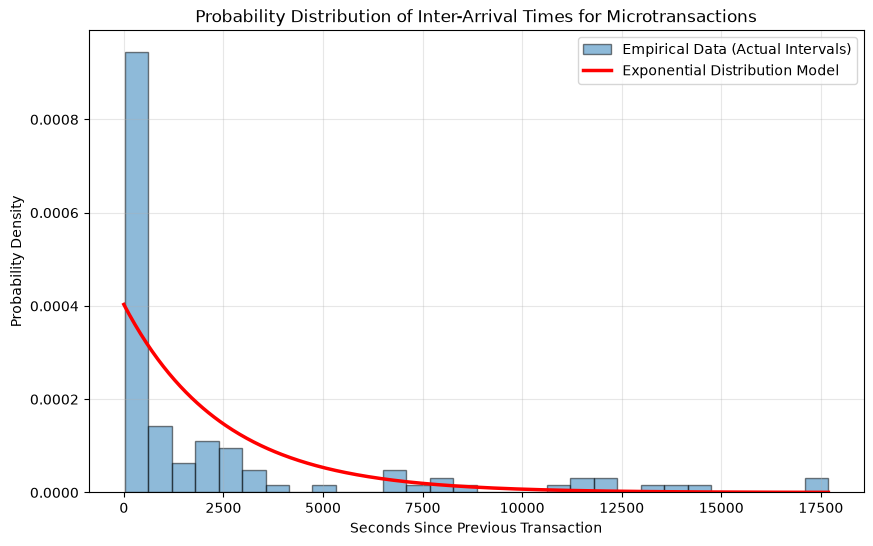

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# FIX: Filter out cross-stream outliers. We only keep intervals under 24 hours.
valid_intervals = df[df['seconds_since_last_txn'] < 86400]
time_intervals = valid_intervals['seconds_since_last_txn'].dropna().astype(float)

# Calculate the mean expected time and the rate parameter (lambda)
expected_time = time_intervals.mean()
lambda_rate = 1 / expected_time

print(f"Mean time between repeat purchases: {expected_time:.2f} seconds")
print(f"Calculated λ (rate of transactions per second): {lambda_rate:.5f}")

# Initialize the plot
plt.figure(figsize=(10, 6))

# Plot the empirical data (Histogram)
plt.hist(time_intervals, bins=30, density=True, alpha=0.5, color='#1f77b4', edgecolor='black', label='Empirical Data (Actual Intervals)')

# Plot the theoretical Exponential Distribution
x_axis = np.linspace(0, time_intervals.max(), 500)
plt.plot(x_axis, expon.pdf(x_axis, scale=expected_time), 'r-', lw=2.5, label=f'Exponential Distribution Model')

# Formatting for portfolio presentation
plt.title('Probability Distribution of Inter-Arrival Times for Microtransactions')
plt.xlabel('Seconds Since Previous Transaction')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)

# Render the graph
plt.show()

Median time to next transaction: 502.0 seconds


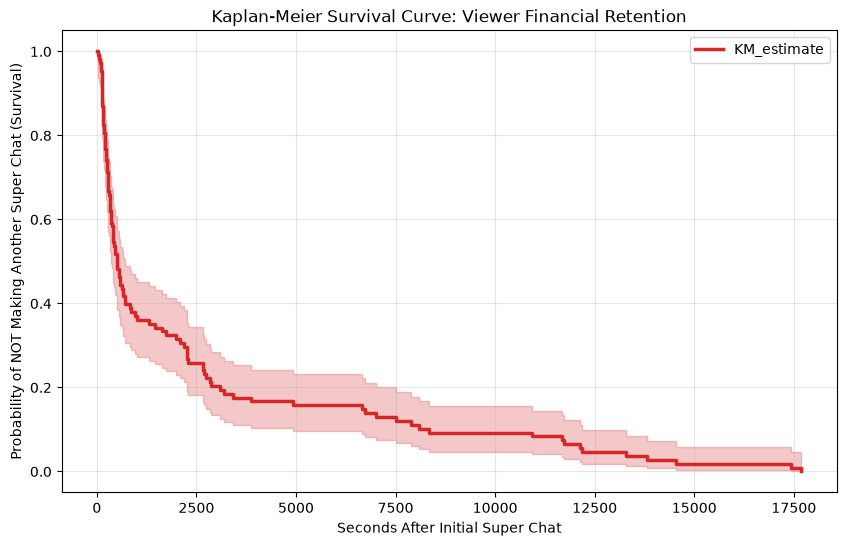

In [4]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# We use the valid (within-stream) intervals you just filtered
time_to_event = valid_intervals['seconds_since_last_txn'].dropna().astype(float)

# Since every row in this dataframe represents a user who DID make a repeat purchase, 
# the 'event_observed' is True (1) for all of them.
events = [1] * len(time_to_event)

# Initialize and fit the model
kmf = KaplanMeierFitter()
kmf.fit(durations=time_to_event, event_observed=events)

# Initialize the plot
plt.figure(figsize=(10, 6))

# Plot the survival curve
kmf.plot_survival_function(color='#d62728', lw=2.5, ci_show=True)

# Portfolio Formatting
plt.title('Kaplan-Meier Survival Curve: Viewer Financial Retention')
plt.xlabel('Seconds After Initial Super Chat')
plt.ylabel('Probability of NOT Making Another Super Chat (Survival)')
plt.grid(True, alpha=0.3)

# Calculate and print the median survival time
median_time = kmf.median_survival_time_
print(f"Median time to next transaction: {median_time} seconds")

# Render
plt.show()